In [45]:
import importlib
import processing_fun
importlib.reload(processing_fun)
from utils import OperonArgs
import matplotlib.pyplot as plt
from os.path import join as pjoin
import numpy as np

# IOB Fits


Reading from configuration file: conf/iob_3.ini

Target: A

All model lengths:
[ 5  6  7  8  9 10 11 12 13 15 16 17 21 25 26 27 29 32]

Equation requested:
((-0.016404) + (1.008748 * ((((((((0.257175 * X1) + log((6.588460 * X9))) / ((-0.551868) * X9)) + 3.385364) ^ 2) ^ 2) ^ 2) - (((((((-22.544157) * X1) - 2.155337) * ((-2.408105) - (0.150053 * X1))) ^ 2) ^ (((-0.828438) * X9) + 0.861086)) * ((0.838943 * X1) + (-0.666098))))))

Equation with pars
-1.008748*((-22.544157*IOB1 - 2.155337)**2*(-0.150053*IOB1 - 2.408105)**2)**(0.861086 - 0.828438*lam)*(0.838943*IOB1 - 0.666098) + 1.008748*(3.385364 - 1.81202751382577*(0.257175*IOB1 + log(6.58846*lam))/lam)**8 - 0.016404

Converted equation:
-b0*((-b1*IOB1 - b2)**2*(-b3*IOB1 - b4)**2)**(b5 - b6*lam)*(b7*IOB1 - b8) + b9*(b10 - b11*(b12*IOB1 + log(b13*lam))/lam)**8 - b14

Number of parameters: 15
Values: [1.008748, 22.544157, 2.155337, 0.150053, 2.408105, 0.861086, 0.828438, 0.838943, 0.666098, 1.008748, 3.385364, 1.81202751382577, 0.257175, 

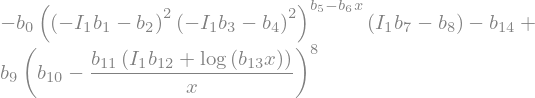


Latex version:
- b_{0} \left(\left(- I_{1} b_{1} - b_{2}\right)^{2} \left(- I_{1} b_{3} - b_{4}\right)^{2}\right)^{b_{5} - b_{6} x} \left(I_{1} b_{7} - b_{8}\right) - b_{14} + b_{9} \left(b_{10} - \frac{b_{11} \left(I_{1} b_{12} + \log{\left(b_{13} x \right)}\right)}{x}\right)^{8}
-b0*((-b1*IOB1 - b2)**2*(-b3*IOB1 - b4)**2)**(b5 - b6*lam)*(b7*IOB1 - b8) + b9*(b10 - b11*(b12*IOB1 + log(b13*lam))/lam)**8 - b14

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Reparameterising expression:
Original number of parameters: 16
Temporary global prefix: c, temporary local prefix: d
Old local parameters: ['IOB1']
Final number of parameters: 10
Of which global: 7 and local: 3
Final values: [-0.0164040000000000, -1.81202751382577, 0.861086, 1.008748, 3.385364, 6.58846, -0.828438000000000]


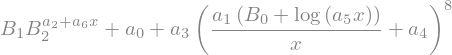

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


Reading from configuration file: conf/iob_3.ini

Target: A

RMSE train: 4.698e-01
		2 sigma: -2.413502172876237 2.428604326152448
		1 sigma: -1.167213217004932 0.7467754455551193
		RMSE: 0.46978388506817814
		RMAE: 0.292070971751957
		2 sigma: -0.3624825653190877 0.7806298168417442
		1 sigma: -0.1728620413187425 0.16526578038788428
Median absolute DF/F 0.03826326027588861

RMSE val: 4.474e-01
		2 sigma: -2.496020561375739 1.813251283968312
		1 sigma: -1.131007511143593 0.6944425682584109
		RMSE: 0.44738643805013295
		RMAE: 0.2804941047987145
		2 sigma: -0.37828222115426624 0.7406945925171969
		1 sigma: -0.16743749907087888 0.1651497983287116
Median absolute DF/F 0.03961546703701524

Reading from configuration file: conf/iob_3.ini

Target: A


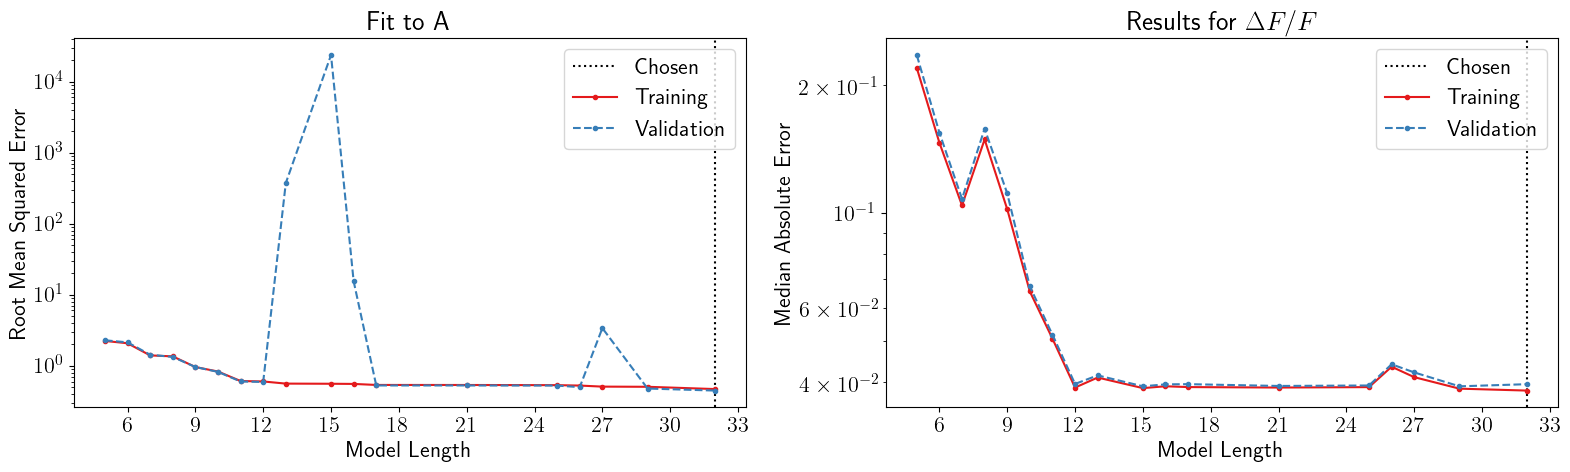

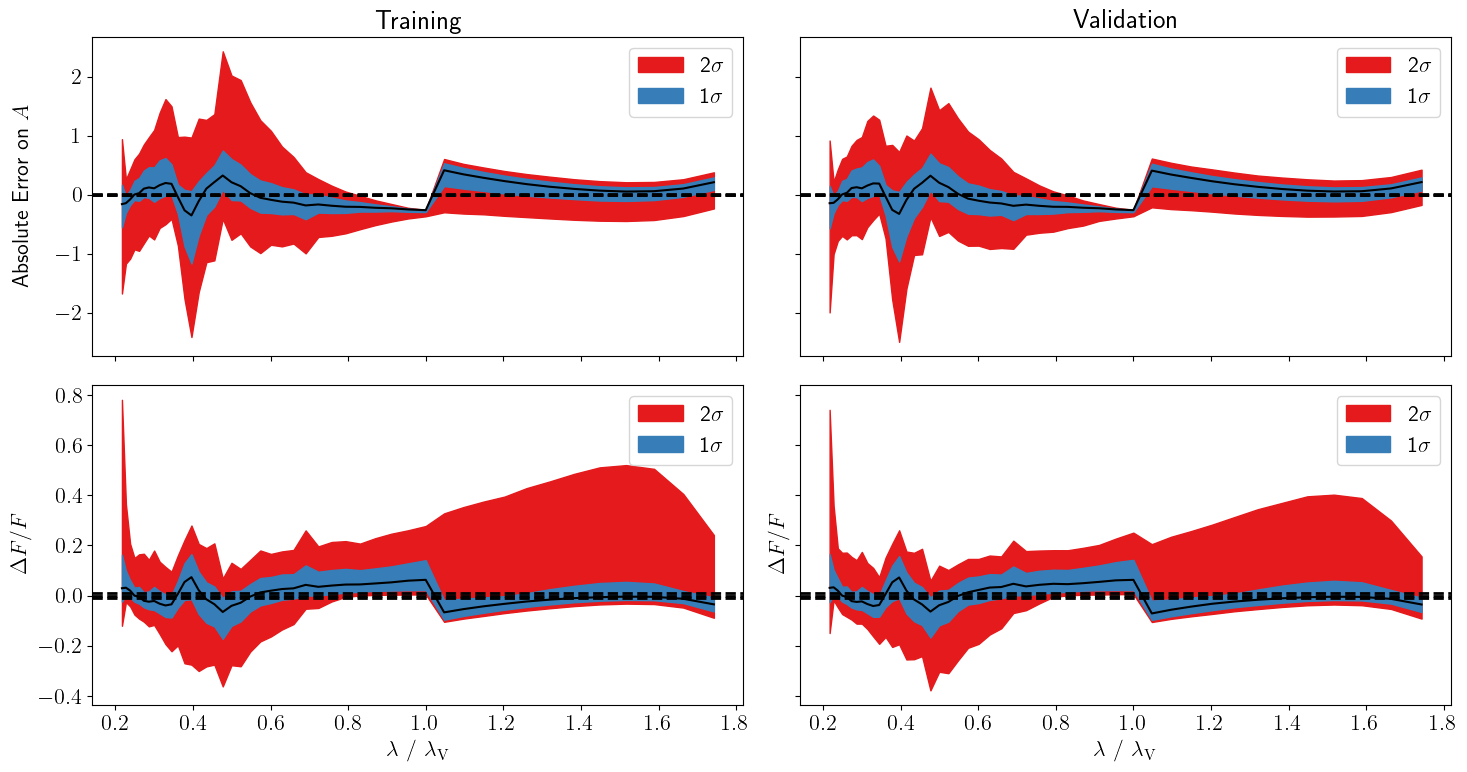

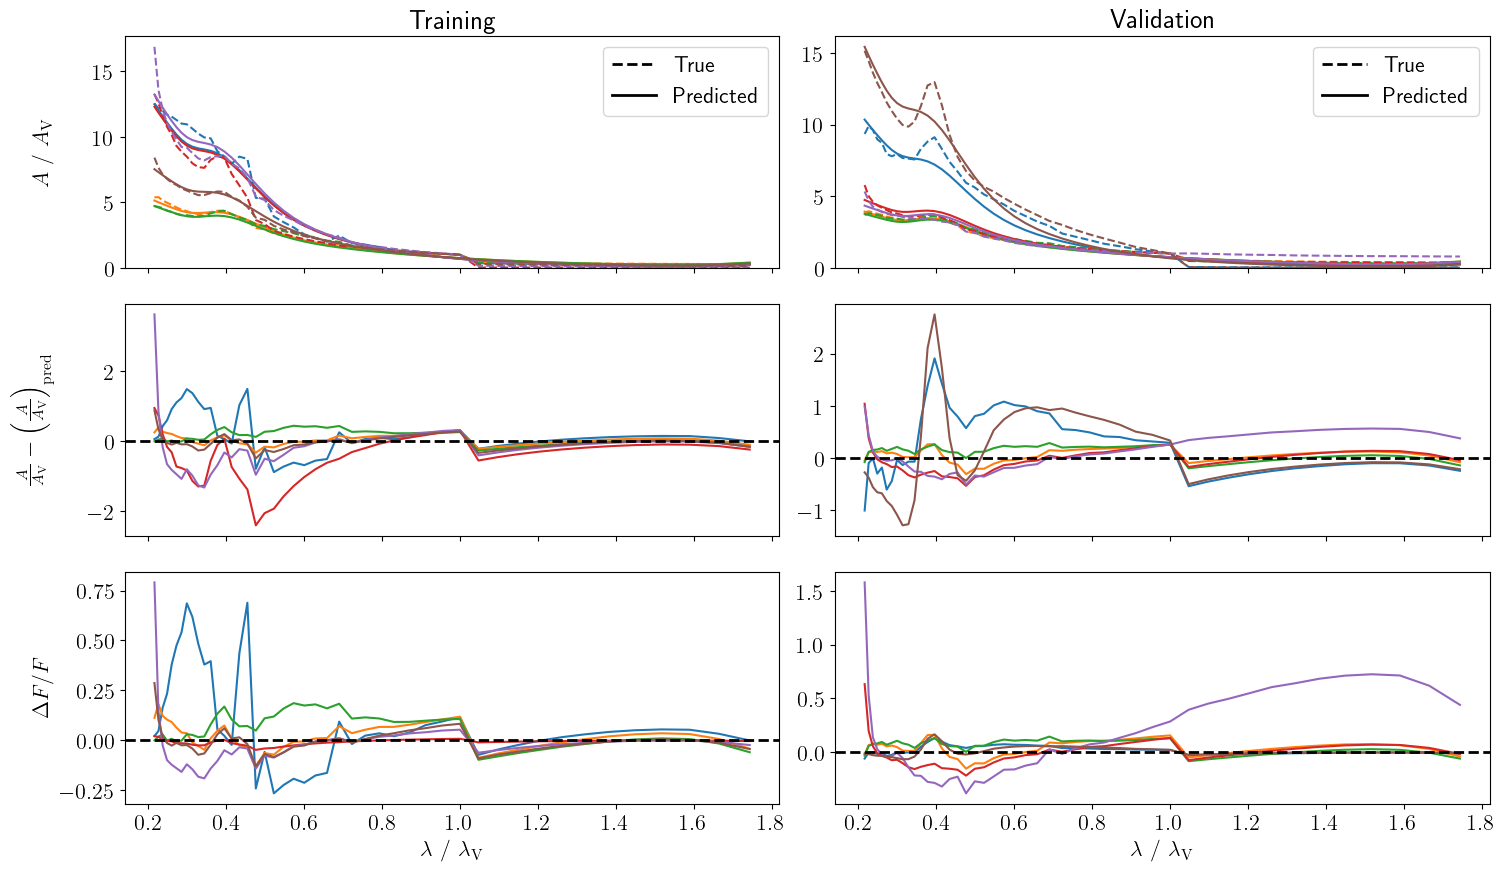

In [46]:
ini_file = 'conf/iob_1.ini'; ilen = 72
ini_file = 'conf/iob_2.ini'; ilen = 51
ini_file = 'conf/iob_3.ini'
ilen = None
processing_fun.plot_pareto(ini_file, ilen=ilen)
processing_fun.prediction_plots(ini_file, ilen=ilen);
processing_fun.plot_example(ini_file, ilen=ilen, nexamples=6);

# Check Distribution of Training and Validation Parameters


Reading from configuration file: conf/iob_0.ini
(46000, 7) (23000, 7)


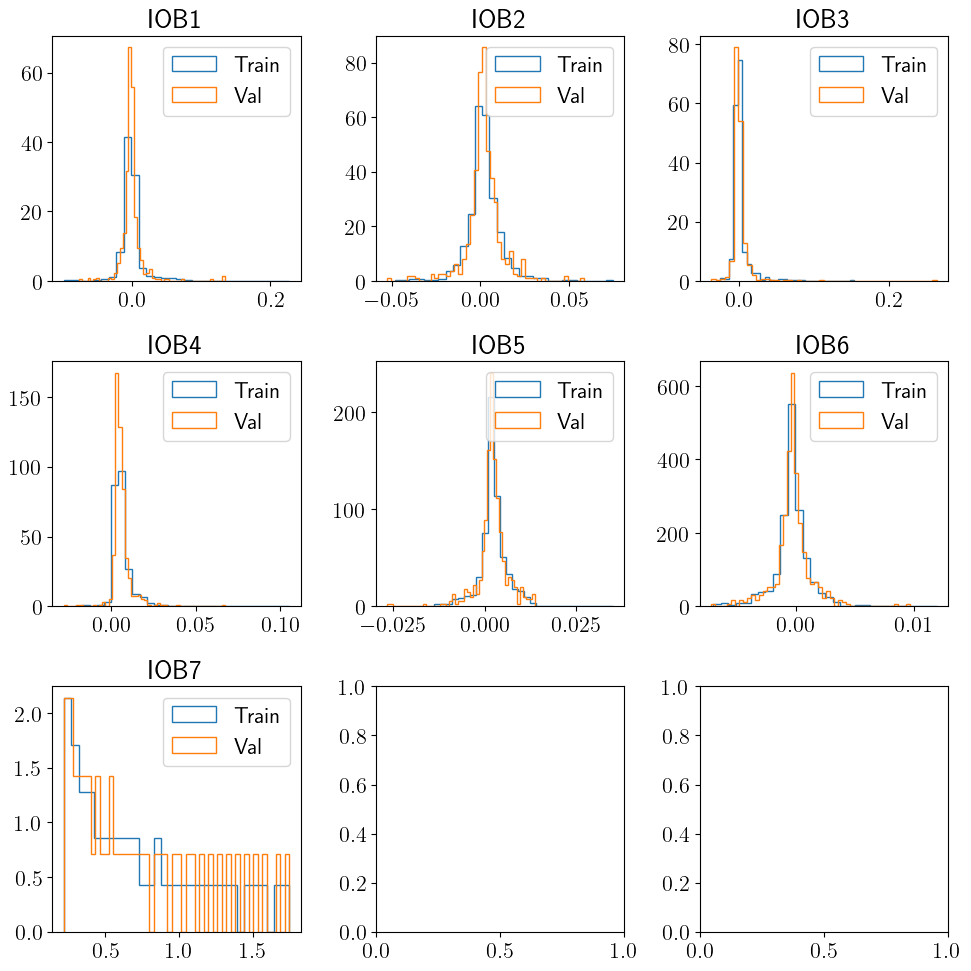

In [114]:
ini_file = 'conf/iob_0.ini'
args = OperonArgs(ini_file)
    
# Load training and validation data
dirname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}')
fname_train = pjoin(dirname, f'{args.in_param}_train_data.txt')
fname_val = pjoin(dirname, f'{args.in_param}_val_data.txt')

with open(fname_train, 'r') as f:
    names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_train, skiprows=1)
X = data[:,2:-1]
y = data[:,-1]

with open(fname_val, 'r') as f:
    val_names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_val, skiprows=1)
Xval = data[:,2:-1]

print(X.shape, Xval.shape)

fig, axs = plt.subplots(3, 3, figsize=(10,10))
for i, ax in enumerate(axs.flatten()[:X.shape[1]]):
    ax.hist(X[:,i], bins=30, density=True, histtype='step', label='Train')
    ax.hist(Xval[:,i], bins=50, density=True, histtype='step', label='Val')
    ax.legend()
    ax.set_title(f'IOB{i+1}')
fig.tight_layout()